# Grad-CAM Demo Using SimpleCNN (CIFAR-10)
This notebook implements Grad-CAM for the SimpleCNN architecture used in class.

## How Grad-CAM Works
Grad-CAM highlights the image regions that most influence a model’s prediction by looking at gradients flowing into the final convolutional layer. The process:
- Run a forward pass to get class scores and keep the last conv feature maps.
- Pick a target class (e.g., the top prediction) and backpropagate its score to get gradients w.r.t. those feature maps.
- Average the gradients over spatial dimensions to get one weight per channel (how important each feature map is for that class).
- Form a class activation map by weighting and summing the feature maps, then apply ReLU to keep only positive influence.
- Resize the activation map to the input image size and overlay it as a heatmap to see where the model is “looking.”

## 1. Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

torch.manual_seed(42)

## 2. Define SimpleCNN

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        self.features = x              # store features for Grad-CAM
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## 3. Load CIFAR-10

In [ ]:
test_transforms = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))
])

test_set = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_transforms)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=True)

classes = test_set.classes

Files already downloaded and verified


## 4. Initialize Model and Load Weights

Here we set up SimpleCNN and load pretrained weights if `simplecnn_cifar10.pth` is available. If the checkpoint is missing, the code trains SimpleCNN on CIFAR-10 (with basic augmentation), saves the weights, and then reloads them so the rest of the notebook can run consistently. The model is moved to the available device (CPU/GPU) and switched to eval mode after loading.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt_path = Path('simplecnn_cifar10.pth')

model = SimpleCNN().to(device)

if ckpt_path.exists():
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f'Loaded weights from {ckpt_path}')
else:
    print('Checkpoint simplecnn_cifar10.pth not found. Training SimpleCNN from scratch...')
    train_transforms = transforms.Compose([
        transforms.Resize((32,32)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))
    ])
    train_set = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=train_transforms)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

    epochs = 5
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader.dataset):.4f}")

    torch.save(model.state_dict(), ckpt_path)
    print(f'Saved trained weights to {ckpt_path}')
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

model.eval()


Files already downloaded and verified
Epoch 1/5 - Loss: 1.5631
Epoch 2/5 - Loss: 1.1220
Epoch 3/5 - Loss: 0.9429
Epoch 4/5 - Loss: 0.8359
Epoch 5/5 - Loss: 0.7419


SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

## 5. Register Backward Hook on Last Conv Layer

The backward hook grabs the gradients flowing from the prediction back into the last convolutional layer. By storing these gradients, we can see how much each activation map influenced the target class. We then average the gradients across spatial dimensions to get one weight per channel and combine those weights with the saved feature maps, producing the Grad-CAM heatmap that highlights the most relevant regions of the image for the prediction.

In [ ]:
gradients = None

def save_gradients(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

model.conv2.register_backward_hook(save_gradients)

## 6. Grad-CAM Computation

Here we perform the actual Grad-CAM math: run the model on the input, pick the target class (by default the top prediction), backpropagate to capture gradients on the last conv feature maps, and average those gradients to get one weight per channel. We then combine the weights with the stored feature maps, apply ReLU to keep only positive influence, and normalize the result into a heatmap that can be overlaid on the image.

In [ ]:
def compute_gradcam(image_tensor, class_idx=None):
    global gradients

    input_tensor = image_tensor.to(device)
    output = model(input_tensor)

    if class_idx is None:
        class_idx = output.argmax().item()

    model.zero_grad()
    target = output[0, class_idx]
    target.backward()

    feature_maps = model.features.detach()[0]  # shape: [64, H, W]
    grads = gradients.detach()[0]               # shape: [64, H, W]

    weights = grads.mean(dim=[1,2])

    # Build 2D CAM on the same device as feature maps
    cam = torch.zeros(feature_maps.shape[1:], dtype=torch.float32, device=feature_maps.device)
    for i, w in enumerate(weights):
        cam += w * feature_maps[i, :, :]

    cam = torch.relu(cam)
    cam -= cam.min()
    cam /= cam.max()

    return cam.detach().cpu().numpy(), class_idx


## 7. Visualization

Here we put everything together: pick a test image, run the model to get its prediction, and compute Grad-CAM for the target class. We then denormalize the image and overlay the heatmap on top of it. The side-by-side view makes it easy to see which regions the model relied on to make its prediction.


In [ ]:
def show_gradcam(image_tensor, cam, class_name):
    img = image_tensor.squeeze().detach().cpu().numpy().transpose(1,2,0)
    img = img * np.array([0.2470,0.2435,0.2616]) + np.array([0.4914,0.4822,0.4465])
    img = np.clip(img, 0, 1)

    # Resize CAM to image size using bilinear interpolation (avoids np.interp 1D limitation)
    cam_tensor = torch.tensor(cam, dtype=torch.float32)[None, None, ...]
    cam_resized = torch.nn.functional.interpolate(cam_tensor, size=img.shape[:2], mode='bilinear', align_corners=False)
    cam_resized = cam_resized.squeeze().cpu().numpy()

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.title('Original')
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title(f'Grad-CAM ({class_name})')
    plt.imshow(img, alpha=0.6)
    plt.imshow(cam_resized, cmap='jet', alpha=0.4)
    plt.axis('off')

    plt.show()


## 8. Run on a Sample CIFAR-10 Image

In this final step we pick a single test image, make the model’s prediction, and compute Grad-CAM for that class. The printed labels show the ground truth and the predicted class, and the visualization overlays the heatmap on the image so you can see exactly which regions drove the decision. This ties together loading the data, running inference, and interpreting the model’s focus.

True label: airplane
Predicted label: ship


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.
/Users/ebezerra/miniconda3/envs/ml4ds/lib/python3.11/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


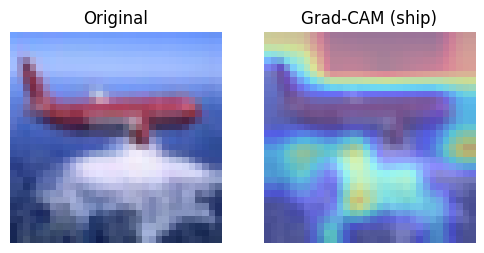

In [ ]:
image, label = next(iter(test_loader))
print("True label:", classes[label[0]])

cam, pred_class = compute_gradcam(image)
print("Predicted label:", classes[pred_class])

show_gradcam(image, cam, classes[pred_class])

## Interpreting the Grad-CAM Result

The example shows an image of an airplane, but the model predicts ship.  
Grad-CAM helps us understand *why* the ConvNet made this incorrect decision by highlighting the regions that contributed most to the predicted class.

---

### 1. What the Model Got Wrong
Although the object is clearly an airplane, the model focuses on visual cues that it mistakenly associates with the ship class. This type of confusion is common in CIFAR-10, especially with:

- low-resolution images (32×32),
- simple ConvNets,
- models trained for only a few epochs.

Both *airplane* and *ship* images in CIFAR-10 often contain similar color patterns (large blue background, horizontal shapes), making early-stage models particularly vulnerable to confusions.

---

### 2. What the Grad-CAM Heatmap Shows

Grad-CAM highlights the **spatial evidence** used by the model for the class “ship”:

- **Warm colors (red/yellow)** = strong evidence for “ship”  
- **Cool colors (blue)** = weak or irrelevant regions

In the attached image, the heatmap shows that the model activated strongly on the blue background and lower bright area, not on the airplane itself. This indicates that the decision was based on contextual cues rather than object features.

**Key observations:**

1. The model focuses on the blue background, which it has learned to associate with water in ship images.  
2. The bright region beneath the airplane is misinterpreted as water foam or waves, reinforcing the ship prediction.  
3. The airplane shape produces only moderate but not dominant activation, meaning the model has not learned robust airplane-specific features (wings, tail geometry, fuselage shape).

---

### 3. Why This Happens

This behavior is typical of undertrained or shallow ConvNets:

- **Few training epochs** → the model learns only coarse patterns (color blobs, low-level textures), not object structure.
- **Low-resolution CIFAR-10 images** → many object details are lost, increasing reliance on background textures.
- **Simple architectures** → insufficient capacity to disentangle subtle inter-class differences.

As a result, the model relies on spurious correlations learned from the dataset:  
“Lots of blue + elongated object → ship.”

---

### 4. How to Interpret This Result

The Grad-CAM heatmap reveals that:

> The model’s misclassification is not random; it systematically relies on incorrect visual cues. Instead of focusing on the airplane’s structural features, it uses background color and texture as primary evidence for the class *ship*.

This is an important teaching moment: a high prediction confidence does not imply meaningful understanding. Grad-CAM exposes the gap between what the model *should* look at and what it *actually* looks at.

---

### 5. What Happens If You Train Longer?

With more epochs (e.g., 20–30):

- Grad-CAM heatmaps become more concentrated on the object,  
- the network learns sharper and more specialized filters,  
- background reliance decreases,  
- misclassifications of this type become less common.

We will typically observe a shift from:
**“background-driven reasoning” → “object-driven reasoning.”**

## Practice Exercises
- Train SimpleCNN for a few more epochs and compare Grad-CAM maps before and after.
- Try a different checkpoint (or random weights) and note how the heatmaps change.
- Swap the target class in Grad-CAM (not the top prediction) and inspect the focus shift.
- Change the hook to an earlier conv layer and observe differences in the activation map.
- Run Grad-CAM on several test images in a loop and count how often the top-1 is correct.
